In [1]:
# import modules
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
cwd = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(cwd, "..", ".."))

# build paths inside the repo
get_data_path = lambda folders, fname: os.path.normpath(
    os.path.join(BASE_DIR, *folders, fname)
)

file_path_training_data = get_data_path(['data', 'output', 'models'], 'training_data.csv')


In [3]:
training_df = pd.read_csv(file_path_training_data)
training_df[:3]

,genepair,A1,A2,A1_entrez,A2_entrez,DepMap_ID,cell_line,Gemini_FDR,raw_LFC,SL,...,colocalisation,interact,n_total_ppi,fet_ppi_overlap,gtex_spearman_corr,gtex_min_mean_expr,gtex_max_mean_expr,GEMINI,LFC,SL_new
0,A3GALT2_ABO,A3GALT2,ABO,127550.0,28.0,ACH-000022,PATU8988S_PANCREAS,0.998944,0.088856,False,...,0.0,False,3.0,0.0,0.114847,0.258739,11.702,0.118768,0.088856,False
1,A3GALT2_ABO,A3GALT2,ABO,127550.0,28.0,ACH-000307,PK1_PANCREAS,0.986587,0.201704,False,...,0.0,False,3.0,0.0,0.114847,0.258739,11.702,0.132501,0.201704,False
2,A3GALT2_ABO,A3GALT2,ABO,127550.0,28.0,ACH-000632,HS944T_SKIN,1.000000,0.069772,False,...,0.0,False,3.0,0.0,0.114847,0.258739,11.702,0.024593,0.069772,False


In [4]:
CATEGORY_ORDER = ['Silenced', 'Normal\n(25th–75th)', 'High\n(top 25%)']

## SL% = (rows where SL_new == True) / (total rows in category) × 100

def compute_sl_rates(df, expr_col):
    non_sil = df.loc[df[expr_col] > 0, expr_col]
    q1_b, q3_b = non_sil.quantile([0.25, 0.75])

    print(f"{expr_col}:  25th pct={q1_b:.3f},  75th pct={q3_b:.3f}")

    def assign_cat(val):
        if val == 0:          return 'Silenced'
        elif val <= q1_b:     return None            # bottom 25% excluded
        elif val <= q3_b:     return 'Normal\n(25th–75th)'
        else:                 return 'High\n(top 25%)'

    df = df.copy()
    df['expr_category'] = df[expr_col].apply(assign_cat)
    df = df.dropna(subset=['expr_category'])

    summary = df.groupby('expr_category')['SL_new'].agg(
        n_total='count',
        n_SL=lambda x: x.sum(),
        n_not_SL=lambda x: (~x).sum(),
        SL_percent=lambda x: x.mean() * 100
    ).reindex(CATEGORY_ORDER).reset_index()

    print(summary.round(2))

    return summary

sl_min = compute_sl_rates(training_df, 'rMinExp_A1A2')
sl_max = compute_sl_rates(training_df, 'rMaxExp_A1A2')


rMinExp_A1A2:  25th pct=0.098,  75th pct=3.159
         expr_category  n_total  n_SL  n_not_SL  SL_percent
0             Silenced    11048   119     10929        1.08
1  Normal\n(25th–75th)    15037   252     14785        1.68
2      High\n(top 25%)     7547   497      7050        6.59
rMaxExp_A1A2:  25th pct=1.227,  75th pct=5.024
         expr_category  n_total  n_SL  n_not_SL  SL_percent
0             Silenced     2194    25      2169        1.14
1  Normal\n(25th–75th)    19510   377     19133        1.93
2      High\n(top 25%)     9757   478      9279        4.90


In [5]:
def compute_fisher_tests(summary, label):
    cats = summary.set_index('expr_category')
    
    for comp, (a, b) in [
        ('Silenced vs Moderate', ('Silenced', 'Normal\n(25th–75th)')),
        ('High vs Moderate',     ('High\n(top 25%)', 'Normal\n(25th–75th)'))
    ]:
        table = [
            [cats.loc[a, 'n_SL'], cats.loc[a, 'n_not_SL']],
            [cats.loc[b, 'n_SL'], cats.loc[b, 'n_not_SL']]
        ]
        OR, p = stats.fisher_exact(table)
        print(f"{label} | {comp}: OR={OR:.3f}, p={p:.3e}")

compute_fisher_tests(sl_min, 'Min expression')
compute_fisher_tests(sl_max, 'Max expression')


Min expression | Silenced vs Moderate: OR=0.639, p=5.455e-05
Min expression | High vs Moderate: OR=4.136, p=5.484e-78
Max expression | Silenced vs Moderate: OR=0.585, p=7.358e-03
Max expression | High vs Moderate: OR=2.614, p=9.425e-43


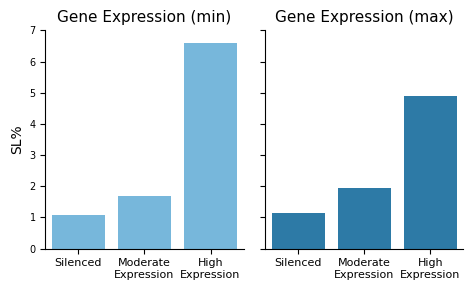

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(4.85, 3.0), sharey=True)

titles = ['Gene Expression (min)', 'Gene Expression (max)']
datasets = [sl_min, sl_max]
colors = ['#56B4E9', '#0072B2']

for ax, data, title, color in zip(axes, datasets, titles, colors):
    sns.barplot(
        data=data, x='expr_category', y='SL_percent',
        order=CATEGORY_ORDER,
        color=color, alpha=0.9, ax=ax
    )
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Silenced', 'Moderate\nExpression', 'High\nExpression'], fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    #ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylim(0,7)
    sns.despine(ax=ax, top=True, right=True)

axes[0].set_ylabel('SL%', fontsize=10)
axes[1].set_ylabel('')

plt.tight_layout()
#figure_path_boxplot = get_data_path(['figures', 'model_on_GEMINI'], 'boxplot_expression_SL.png')
#plt.savefig(figure_path_boxplot, dpi=500, bbox_inches='tight')
plt.show()


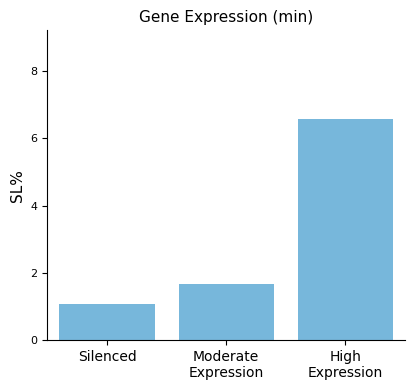

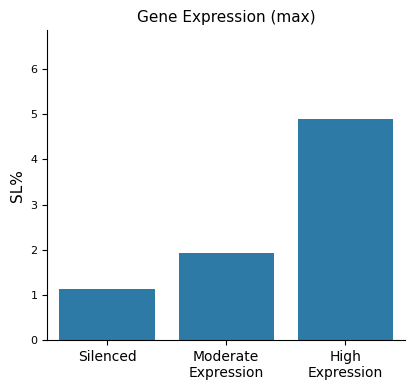

In [10]:
figure_path_sup1_min = get_data_path(['figures', 'supp_figures'], 'sup1_bar_expressed_genes_min.png')
figure_path_sup1_max = get_data_path(['figures', 'supp_figures'], 'sup1_bar_expressed_genes_max.png')

titles = ['Gene Expression (min)', 'Gene Expression (max)']
datasets = [sl_min, sl_max]
colors = ['#56B4E9', '#0072B2']

# Comment out the next line to skip saving
#save_paths = [figure_path_sup1_min, figure_path_sup1_max]

for i, (data, title, color) in enumerate(zip(datasets, titles, colors)):
    fig, ax = plt.subplots(figsize=(4.25, 4.0))

    sns.barplot(
        data=data, x='expr_category', y='SL_percent',
        order=CATEGORY_ORDER,
        color=color, alpha=0.9, ax=ax
    )
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Silenced', 'Moderate\nExpression', 'High\nExpression'], fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('SL%', fontsize=11)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_ylim(0, data['SL_percent'].max() * 1.4)
    sns.despine(ax=ax, top=True, right=True)

    plt.tight_layout()
    try:
        plt.savefig(save_paths[i], dpi=500, bbox_inches='tight')
    except NameError:
        pass
    plt.show()
